# **Lab 03:** Transfer Learning with PyTorch and Model Improvement

## Graded Individual Activity:

In this activity, we will carry out a series of tests to evaluate the performance of our image classification model. The objective is to correctly identify whether an image contains the face of a specific student or corresponds to a background. To do this, we have defined two main labels:

##### **Label 1:** `Student Name`  
##### **Label 2:** `Background` (images that do not contain the student’s face)

#### **Tests:**

The tests will be conducted using different types of input images to verify the model’s accuracy in scenarios not seen during training:

1. **Input image:** A photo of the student that is not included in the training folder (take a photo on the day of the presentation using your webcam).  
   **Required output label:** `Student Name`

2. **Input image:** A background image that is not included in the training folder (the student presenting before you will give you a search keyword; you may download the image from Google Images).  
   **Required output label:** `Background`

3. **Input image:** A photo of a different face (not the student’s face) that is not included in the training folders (the student presenting before you will give you the name of a celebrity who resembles you; you may download the image from Google Images).  
   **Required output label:** `Background`

##### **Hyperparameter Testing:**

Additionally, you may explore the impact of various hyperparameters on the model’s performance. Examples of hyperparameters to adjust include:

- Increasing the number of images in the dataset  
- Changing the loss function  
- Changing the optimizer  
- Changing the number of training epochs  
- Changing the batch size  

These tests and adjustments will allow you to optimize the model to achieve the best possible accuracy in image classification.

##### **Results Presentation**

Students will present their results in class using a `streamlit` app. The final grade will depend on the successful completion of the 3 tests.

### **Grading Rubric (10 points)**

The Streamlit app should be working correctly during presentation to get points.

| Criterion | Points |
|----------|--------|
| Test 1: Correct classification of student's new photo (`Student Name`) | 2.5 |
| Test 2: Correct classification of unseen background image (`Background`) | 2.5 |
| Test 3: Correct classification of a different face (celebrity look-alike) as `Background` | 5 |
| **Total** | **10** |

### **Scoring Rules**

- Each test is graded as **pass (full points)** or **fail (0 points)**.
- If the model predicts the required label correctly → full points for that test.
- If the prediction is incorrect → 0 points for that test.
- Test 3 has the highest weight because it evaluates the model’s ability to generalize and avoid false positives.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import itertools
import copy
import os
import json
import matplotlib.pyplot as plt

# Definir dispositivo (usar GPU dedicada si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [2]:
# Cargar y transformar el dataset
data_dir = './dataset'

# Transformaciones de datos (Data Augmentation para entrenamiento)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para validación
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Cargar dataset (sin transformaciones globales para aplicarlas de forma independiente luego)
full_dataset = datasets.ImageFolder(root=data_dir, transform=None)
class_names = full_dataset.classes
print(f"Clases detectadas: {class_names}")

# Guardar los nombres de clases para la aplicación en Streamlit
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

# Semilla para reproducibilidad
torch.manual_seed(42)

# Dividir en entrenamiento (80%) y validación (20%)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Creamos un Wrapper para aplicar transformaciones diferentes a Train y Validation
class DatasetFromSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

train_dataset = DatasetFromSubset(train_subset, transform=train_transform)
val_dataset = DatasetFromSubset(val_subset, transform=val_transform)

print(f"Set de Entrenamiento: {len(train_dataset)} imágenes.")
print(f"Set de Validación: {len(val_dataset)} imágenes.")

Clases detectadas: ['Aldrin Chavez', 'Background']
Set de Entrenamiento: 677 imágenes.
Set de Validación: 170 imágenes.


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False, num_workers=0)

In [10]:
# Optimización de hiperparámetros - Grid Search
print("Configurando y ejecutando Grid Search...")

# Definimos el espacio de búsqueda
hyperparams = {
    'lr': [0.001, 0.0001],
    'batch_size': [16, 32],
    'optimizer': ['Adam', 'SGD']
}

keys = hyperparams.keys()
combinations = [dict(zip(keys, v)) for v in itertools.product(*hyperparams.values())]

best_val_acc = 0.0
best_model_wts = None
best_params = {}

epochs = 5  # Reducido para acelerar la búsqueda de hiperparámetros

for i, params in enumerate(combinations):
    print(f"\n--- Probando combinación {i+1}/{len(combinations)}: {params} ---")
    
    
    # Modelo preentrenado ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Congelar capas base (solo entrenamos la última capa)
    for param in model.parameters():
        param.requires_grad = False
        
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    
    if params['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.fc.parameters(), lr=params['lr'])
    else:
        # Añadimos momentum para SGD
        optimizer = optim.SGD(model.fc.parameters(), lr=params['lr'], momentum=0.9)
        
    for epoch in range(epochs):
        model.train()
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_corrects += torch.sum(preds == labels.data)
            
        # Validación
        model.eval()
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
                
        val_acc = val_corrects.double() / val_size
        
    print(f"Resultado final de combinación -> Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:

        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        best_params = params

print(f"\n✅ Mejores hiperparámetros encontrados: {best_params} con precisión de validación de {best_val_acc:.4f}")

Configurando y ejecutando Grid Search...

--- Probando combinación 1/8: {'lr': 0.001, 'batch_size': 16, 'optimizer': 'Adam'} ---
Resultado final de combinación -> Val Acc: 0.9588

--- Probando combinación 2/8: {'lr': 0.001, 'batch_size': 16, 'optimizer': 'SGD'} ---
Resultado final de combinación -> Val Acc: 0.9588

--- Probando combinación 3/8: {'lr': 0.001, 'batch_size': 32, 'optimizer': 'Adam'} ---
Resultado final de combinación -> Val Acc: 0.9588

--- Probando combinación 4/8: {'lr': 0.001, 'batch_size': 32, 'optimizer': 'SGD'} ---
Resultado final de combinación -> Val Acc: 0.9235

--- Probando combinación 5/8: {'lr': 0.0001, 'batch_size': 16, 'optimizer': 'Adam'} ---
Resultado final de combinación -> Val Acc: 0.8529

--- Probando combinación 6/8: {'lr': 0.0001, 'batch_size': 16, 'optimizer': 'SGD'} ---
Resultado final de combinación -> Val Acc: 0.8647

--- Probando combinación 7/8: {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'Adam'} ---
Resultado final de combinación -> Val Acc: 


--- Entrenando modelo final ---
Epoch 1/10 | Train Acc: 0.9114 | Val Acc: 0.9588
Epoch 2/10 | Train Acc: 0.9734 | Val Acc: 0.9706
Epoch 3/10 | Train Acc: 0.9793 | Val Acc: 0.9529
Epoch 4/10 | Train Acc: 0.9970 | Val Acc: 0.9647
Epoch 5/10 | Train Acc: 0.9941 | Val Acc: 0.9235
Epoch 6/10 | Train Acc: 0.9970 | Val Acc: 0.9588
Epoch 7/10 | Train Acc: 1.0000 | Val Acc: 0.9588
Epoch 8/10 | Train Acc: 0.9970 | Val Acc: 0.9353
Epoch 9/10 | Train Acc: 0.9985 | Val Acc: 0.9588
Epoch 10/10 | Train Acc: 0.9911 | Val Acc: 0.9824
✅ Modelo final guardado exitosamente como 'best_model.pth'


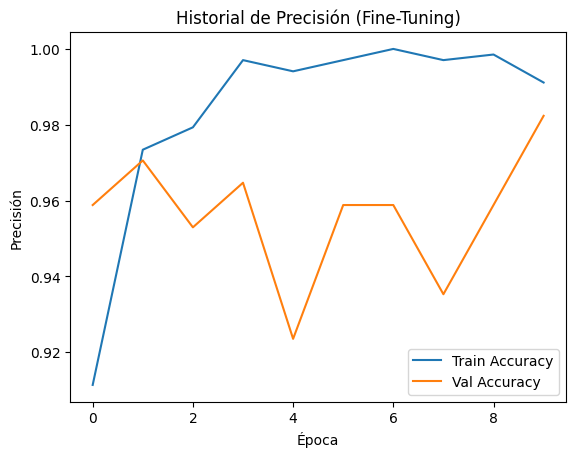

In [13]:
# Entrenamiento Final (Fine Tuning de toda la red) con los mejores parámetros
print("\n--- Entrenando modelo final ---")
final_epochs = 10

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False, num_workers=0)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Fine Tuning: Permitir que TODAS las capas se actualicen
for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Se recomienda usar un Learning Rate más bajo para fine tuning
final_lr = best_params['lr'] * 0.1

if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=final_lr)
else:
    optimizer = optim.SGD(model.parameters(), lr=final_lr, momentum=0.9)

history = {'train_acc': [], 'val_acc': []}

for epoch in range(final_epochs):
    model.train()
    running_corrects = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        running_corrects += torch.sum(preds == labels.data)
        
    train_acc = running_corrects.double() / train_size
    history['train_acc'].append(train_acc.item())
    
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
            
    val_acc = val_corrects.double() / val_size
    history['val_acc'].append(val_acc.item())
    
    print(f"Epoch {epoch+1}/{final_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

# Guardar el modelo final entrenado
torch.save(model.state_dict(), 'best_model.pth')
print("✅ Modelo final guardado exitosamente como 'best_model.pth'")

# Gráfica del Historial de Precisión
plt.figure()
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Historial de Precisión (Fine-Tuning)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.show()